# 02 — Baseline Evaluation

This notebook evaluates the **rule-based POS tagger** on the UD English Web Treebank dev and test splits.

**Metrics:** Overall accuracy, per-tag precision/recall/F1, and confusion matrix.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.parser import parse_conllu, get_forms_and_tags
from src.lexicon import Lexicon
from src.tagger import RuleBasedTagger
from src.evaluate import Evaluator, UPOS_TAGS

plt.rcParams['figure.figsize'] = (14, 10)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

## 1. Load Data & Build Lexicon

In [2]:
# Parse all splits
train_sents = parse_conllu('../data/en_ewt-ud-train.conllu')
dev_sents   = parse_conllu('../data/en_ewt-ud-dev.conllu')
test_sents  = parse_conllu('../data/en_ewt-ud-test.conllu')

print(f'Train: {len(train_sents):,} sentences, {sum(len(s) for s in train_sents):,} tokens')
print(f'Dev  : {len(dev_sents):,} sentences, {sum(len(s) for s in dev_sents):,} tokens')
print(f'Test : {len(test_sents):,} sentences, {sum(len(s) for s in test_sents):,} tokens')

Train: 12,544 sentences, 204,577 tokens
Dev  : 2,001 sentences, 25,147 tokens
Test : 2,077 sentences, 25,094 tokens


In [3]:
# Build lexicon from training data
lexicon = Lexicon().build(train_sents)
print(lexicon)

# Coverage on dev/test
for name, sents in [('Dev', dev_sents), ('Test', test_sents)]:
    known, total, pct = lexicon.coverage(sents)
    print(f'{name} coverage: {known:,}/{total:,} ({pct:.1f}%)')

Lexicon(vocab=16,654, tokens=204,577, tags=17)
Dev coverage: 23,438/25,147 (93.2%)
Test coverage: 23,212/25,094 (92.5%)


## 2. Baseline Evaluation (Dev Set)

In [4]:
# Tag dev set with baseline tagger (no innovation)
tagger = RuleBasedTagger(lexicon, use_innovation=False)
dev_corpus = get_forms_and_tags(dev_sents)
dev_tagged = tagger.tag_corpus(dev_corpus)

# Compute metrics
evaluator = Evaluator()
dev_acc = evaluator.accuracy(dev_tagged)
dev_per_tag = evaluator.per_tag_metrics(dev_tagged)

print(f'\n=== Dev Set Baseline Accuracy: {dev_acc:.4f} ({dev_acc*100:.2f}%) ===')


=== Dev Set Baseline Accuracy: 0.8722 (87.22%) ===


In [5]:
# Per-tag metrics table
df_metrics = pd.DataFrame(dev_per_tag).T
df_metrics = df_metrics.sort_values('f1', ascending=False)
df_metrics['support'] = df_metrics['support'].astype(int)
print(df_metrics.to_string())

       precision  recall      f1  support
PUNCT     0.9831  0.9841  0.9836     3075
CCONJ     0.9830  0.9653  0.9741      779
PRON      0.9664  0.9308  0.9483     2225
DET       0.9171  0.9611  0.9386     1900
AUX       0.8046  0.9930  0.8889     1567
NUM       0.9136  0.8564  0.8841      383
ADP       0.8588  0.8891  0.8737     2038
ADJ       0.9127  0.8349  0.8720     1865
NOUN      0.8018  0.8772  0.8378     4210
VERB      0.8735  0.7983  0.8342     2707
ADV       0.9346  0.7427  0.8277     1232
PART      0.7267  0.8671  0.7907      647
PROPN     0.8460  0.7033  0.7681     1867
SCONJ     0.6491  0.6196  0.6340      397
INTJ      0.4309  0.7043  0.5347      115
SYM       0.3333  0.3827  0.3563       81
X         0.2222  0.0678  0.1039       59


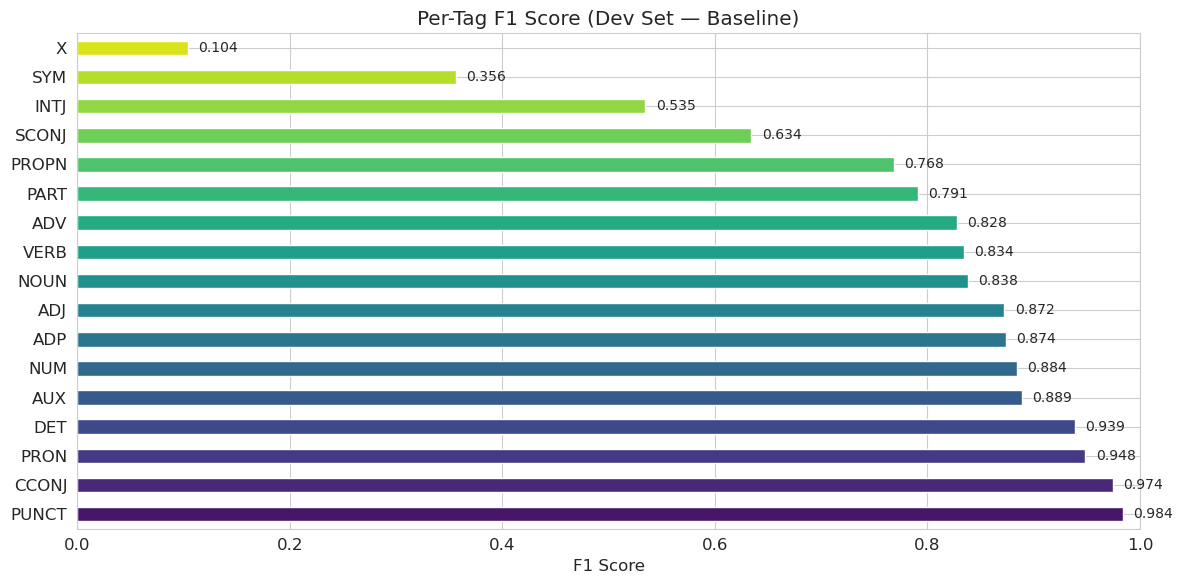

In [6]:
# Per-tag F1 bar chart
fig, ax = plt.subplots(figsize=(12, 6))
colors = sns.color_palette('viridis', len(df_metrics))
df_metrics['f1'].plot(kind='barh', ax=ax, color=colors)
ax.set_xlabel('F1 Score')
ax.set_title('Per-Tag F1 Score (Dev Set — Baseline)')
ax.set_xlim(0, 1)
for i, v in enumerate(df_metrics['f1']):
    ax.text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=10)
plt.tight_layout()
plt.savefig('../outputs/per_tag_f1_baseline.png', dpi=150)
plt.show()

## 3. Confusion Matrix

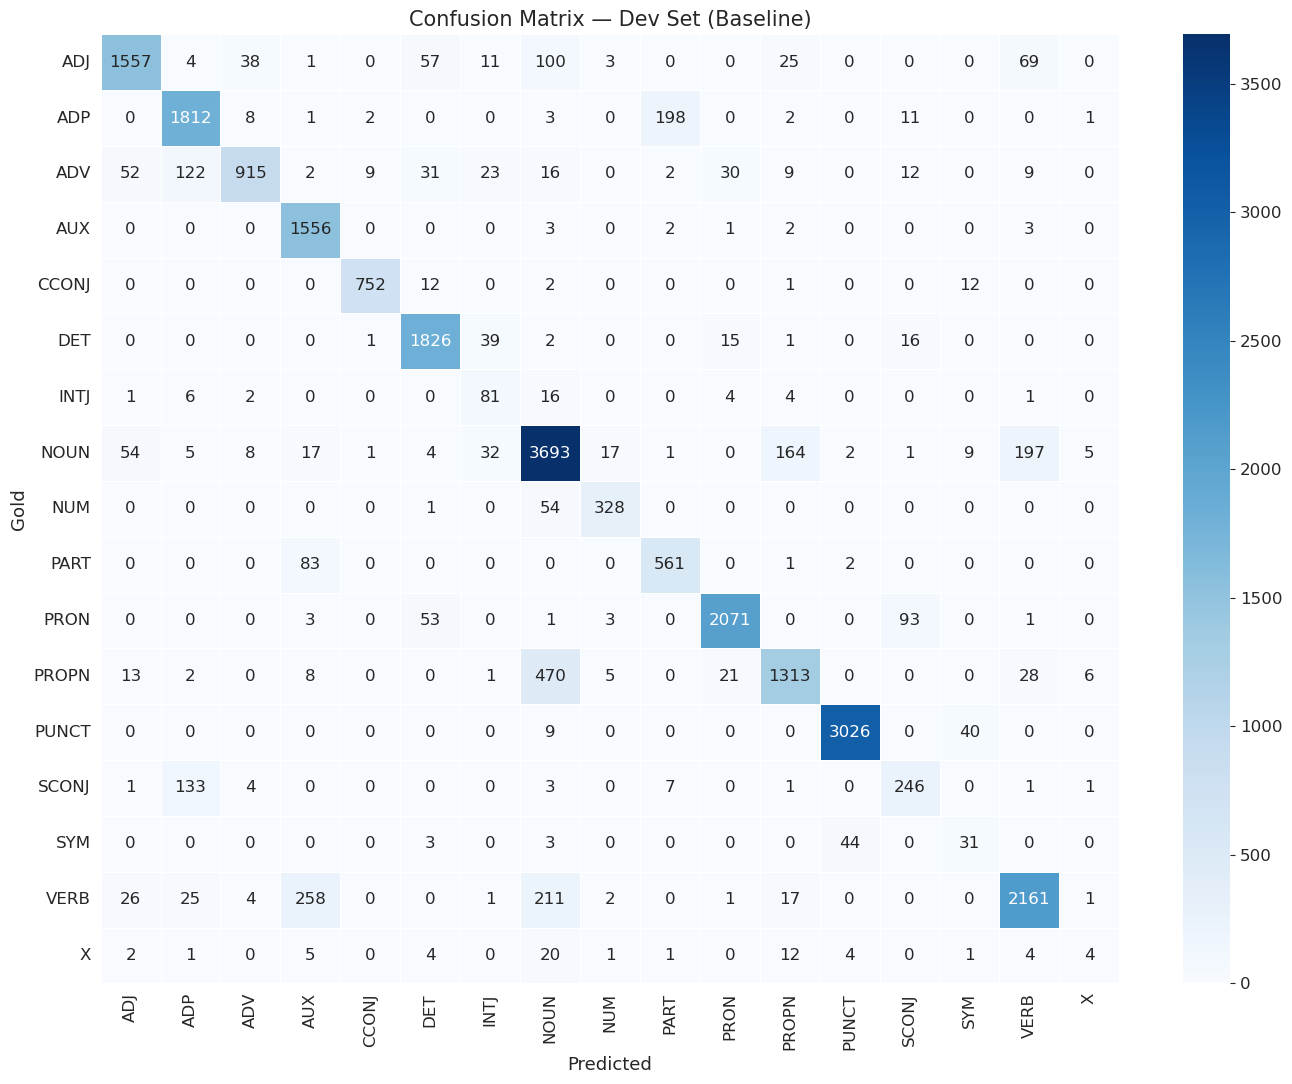

In [7]:
# Confusion matrix heatmap
cm = evaluator.confusion_matrix(dev_tagged)

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=UPOS_TAGS,
            yticklabels=UPOS_TAGS, cmap='Blues', ax=ax, linewidths=0.5)
ax.set_xlabel('Predicted', fontsize=13)
ax.set_ylabel('Gold', fontsize=13)
ax.set_title('Confusion Matrix — Dev Set (Baseline)', fontsize=15)
plt.tight_layout()
plt.savefig('../outputs/confusion_matrix.png', dpi=150)
plt.show()

## 4. Test Set Evaluation

In [8]:
# Tag and evaluate test set
test_corpus = get_forms_and_tags(test_sents)
test_tagged = tagger.tag_corpus(test_corpus)

test_acc = evaluator.accuracy(test_tagged)
test_per_tag = evaluator.per_tag_metrics(test_tagged)

print(f'\n=== Test Set Baseline Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%) ===')
print()
df_test = pd.DataFrame(test_per_tag).T.sort_values('f1', ascending=False)
df_test['support'] = df_test['support'].astype(int)
print(df_test.to_string())


=== Test Set Baseline Accuracy: 0.8763 (87.63%) ===

       precision  recall      f1  support
PUNCT     0.9835  0.9803  0.9819     3096
CCONJ     0.9902  0.9633  0.9766      736
PRON      0.9639  0.9251  0.9441     2164
DET       0.9169  0.9594  0.9377     1897
AUX       0.8183  0.9955  0.8982     1543
ADJ       0.9109  0.8462  0.8774     1788
ADP       0.8685  0.8840  0.8762     2025
ADV       0.9477  0.7767  0.8537     1191
VERB      0.8879  0.8119  0.8482     2605
NUM       0.8767  0.8137  0.8440      542
NOUN      0.8054  0.8804  0.8413     4123
PART      0.7210  0.8921  0.7975      649
PROPN     0.8759  0.7248  0.7932     2075
SCONJ     0.6059  0.5885  0.5971      384
INTJ      0.4533  0.8430  0.5896      121
SYM       0.4476  0.5664  0.5000      113
X         0.0000  0.0000  0.0000       42


In [9]:
# Save results
os.makedirs('../outputs', exist_ok=True)
results = {
    'dev_accuracy': round(dev_acc, 4),
    'test_accuracy': round(test_acc, 4),
    'dev_per_tag': dev_per_tag,
    'test_per_tag': test_per_tag,
}
with open('../outputs/results_baseline.json', 'w') as f:
    json.dump(results, f, indent=2)
print('Saved results to outputs/results_baseline.json')

Saved results to outputs/results_baseline.json
